## Double pendulum dataset

In [11]:
import os
import torch
if not os.getcwd().endswith("ScalarEMLP"):
    os.chdir("../")
# print(os.getcwd())
root_dir=os.path.join(os.getcwd(), *"experiments/datasets/ODEDynamics/DoubleSpringPendulum".split("/"))
file_name=os.path.join(root_dir,"trajectories_5000_5_0.2_30.pz")
zs=torch.load(file_name, weights_only=False)

print(zs.shape)
print(zs[0].shape)

# p1=os.path.join(os.getcwd(), *"datasets/ODEDynamics/DoubleSpringPendulum".split("/"))
# print(p1)

(5000, 5, 12)
(5, 12)


In [12]:
import numpy as np 
from experiments.trainer.hamiltonian_dynamics import *


## 3D visualization

In [13]:
from experiments.trainer.hamiltonian_dynamics import CoupledPendulumAnimation

import numpy as np
from IPython.display import HTML

# Convert from torch.Tensor to numpy
qt = zs[:,:,:3]  # (T, n, d)
# print(qt)


# Visualize
# ani = CoupledPendulumAnimation(qt)
# HTML(ani.animate())

<PjitFunction of <function hamiltonian_dynamics at 0x000001906ED24D60>>
<PjitFunction of <function hamiltonian_dynamics at 0x0000019055C11EE0>>
<PjitFunction of <function hamiltonian_dynamics at 0x0000019055C12E80>>
<PjitFunction of <function hamiltonian_dynamics at 0x000001906EE5C360>>
<PjitFunction of <function hamiltonian_dynamics at 0x000001906EE5D8A0>>
<PjitFunction of <function hamiltonian_dynamics at 0x000001906EE5EB60>>
<PjitFunction of <function hamiltonian_dynamics at 0x000001906EE5EF20>>
<PjitFunction of <function hamiltonian_dynamics at 0x0000019074EEC400>>
<PjitFunction of <function hamiltonian_dynamics at 0x0000019074EEE200>>
<PjitFunction of <function hamiltonian_dynamics at 0x0000019074EEF4C0>>
<PjitFunction of <function hamiltonian_dynamics at 0x000001907664C360>>
<PjitFunction of <function hamiltonian_dynamics at 0x000001907664D4E0>>
<PjitFunction of <function hamiltonian_dynamics at 0x000001907664EDE0>>
<PjitFunction of <function hamiltonian_dynamics at 0x00000190766

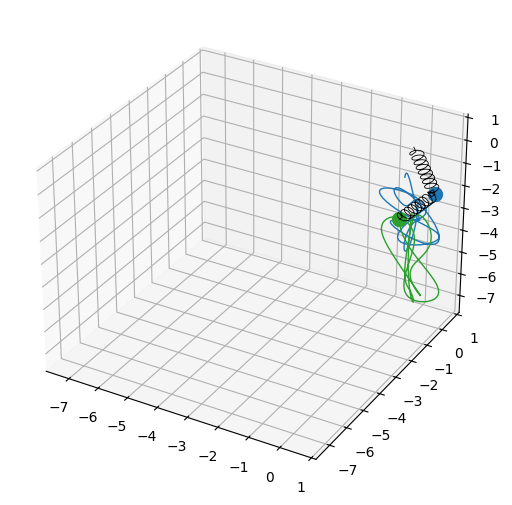

In [14]:
from experiments.trainer.hamiltonian_dynamics import *
from experiments.trainer.hamiltonian_dynamics import DoubleSpringPendulum
from IPython.display import HTML
ndata=5000
data_config={'chunk_len':5,'dt':0.2,'integration_time':30,'regen':False}
dsp=DoubleSpringPendulum(n_systems=ndata,**data_config)


anim=dsp.animate()
HTML(anim)  # In Jupyter Notebook

In [15]:
n_systems, dt, integration_time,chunk_len=500,0.2,30,5
zs = dsp.generate_trajectory_data(n_systems, dt, integration_time)
Zs = np.asarray(dsp.chunk_training_data(zs, chunk_len))
os.makedirs(root_dir, exist_ok=True)
root_dir = os.path.join(os.getcwd(), *f"datasets/ODEDynamics/{dsp.__class__.__name__}".split("/"))
filename = os.path.join(root_dir, f"trajectories_{n_systems}_{chunk_len}_{dt}_{integration_time}.pt")
torch.save(Zs, filename)

<PjitFunction of <function hamiltonian_dynamics at 0x0000019017375DA0>>
<PjitFunction of <function hamiltonian_dynamics at 0x0000019017B69DA0>>
<PjitFunction of <function hamiltonian_dynamics at 0x0000019017B6B560>>
<PjitFunction of <function hamiltonian_dynamics at 0x00000190193D4720>>
<PjitFunction of <function hamiltonian_dynamics at 0x00000190193D5DA0>>


In [27]:
import torch
import numpy

torch.serialization.add_safe_globals([numpy._core.multiarray._reconstruct])
filename = os.path.join(root_dir, f"trajectories_{5000}_{chunk_len}_{dt}_{integration_time}.pt")

with torch.serialization.safe_globals([numpy._core.multiarray._reconstruct]):
    Zs_new = torch.load(filename, weights_only=True)
print(Zs_new.shape)

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy.ndarray was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy.ndarray])` or the `torch.serialization.safe_globals([numpy.ndarray])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with weight

## dataset analysis

In [16]:
ndata=5000
data_config={'chunk_len':5,'dt':0.2,'integration_time':30,'regen':False}
dsp=DoubleSpringPendulum(n_systems=ndata,**data_config)

# data length
print("data length:", len(dsp))

# chunk length
print("chunk length:",dsp.T)

# whole trajectory length
print("whole trajectory length:",dsp.T_long)

# trajectory data shape
print("trajectory data shape:", dsp.Zs.shape)

# trajectory data sample
print("trajectory data sample:", dsp.Zs[0])



data length: 5000
chunk length: [0.  0.2 0.4 0.6 0.8]
whole trajectory length: [ 0.         0.2        0.4        0.6        0.8        1.
  1.2        1.4        1.6        1.8000001  2.         2.2
  2.4        2.6000001  2.8        3.         3.2        3.4
  3.6000001  3.8        4.         4.2000003  4.4        4.6
  4.8        5.         5.2000003  5.4        5.6        5.8
  6.         6.2000003  6.4        6.6        6.8        7.
  7.2000003  7.4        7.6        7.8        8.         8.2
  8.400001   8.6        8.8        9.         9.2        9.400001
  9.6        9.8       10.        10.2       10.400001  10.6
 10.8       11.        11.2       11.400001  11.6       11.8
 12.        12.2       12.400001  12.6       12.8       13.
 13.2       13.400001  13.6       13.8       14.        14.2
 14.400001  14.6       14.8       15.        15.2       15.400001
 15.6       15.8       16.        16.2       16.4       16.6
 16.800001  17.        17.2       17.4       17.6       17.8

In [17]:
from torchview import draw_graph
# print(os.getcwd())

# Load your model from the .t file
# model = torch.load("experiments/hnn_results/scalars_HNNs_1.t") 
# print(model)
# model_graph = draw_graph(model, input_size=(1, 3, 224, 224), expand_nested=True) # Adjust input_size
# model_graph.visual_graph 